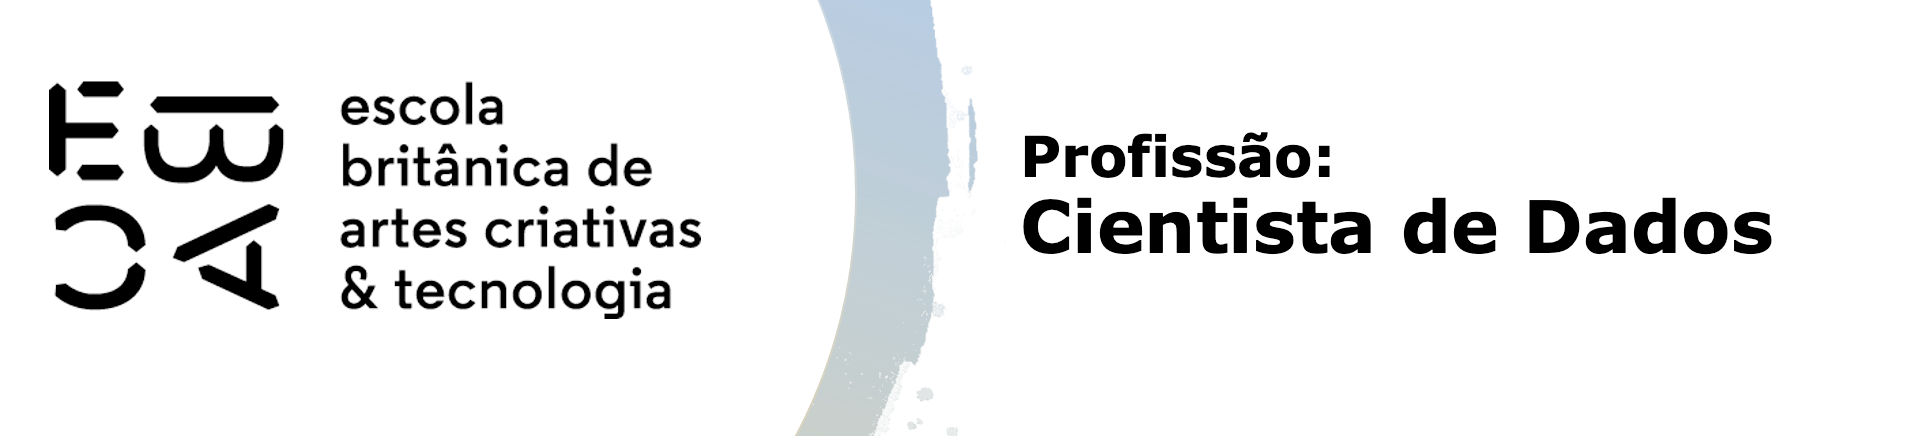

# Tarefa

Carregue a base ```NFP.ftr```. Essa base é proveniente do projeto #AMABiliDados, e contém dados da nota fiscal paulista cadastrados para doação automática para a AMA, Associação de Amigos do Autista. 

A *Nota Fiscal Paulista* é um programa de incentivo do governo do estado de São Paulo, que retorna um pedacinho do ICMS ao consumidor sempre que solicita o registro do seu CPF na nota. Nesse programa, o contribuinte pode direcionar seus créditos a uma ONG, e quando faz isso, sempre que faz esse consumidor cadastrado faz uma compra, os créditos de notas emitidas pelo mesmo estabelecimento não identificadas (notas sem CPF) são "arrastados" para a ONG na forma de uma doação.

Clique no link, caso queira saber mais sobre a [AMA](https://www.ama.org.br/site/).<br>
Clique no link, caso queira saber como o cidadão pode ser um [doador da NFP](https://doacao1.ama.org.br/sitenfp).

Essa base possui dados das notas cujos contribuintes direcionaram seus créditos à AMA. Seus campos estão descritos abaixo:

|Campo|Descrição|
|:-|:-|
|CNPJ emit.| CNPJ do emitente da nota|
|Emitente| Nome fantasia do emitente da nota|
|No.| Número da nota fiscal|
|Data Emissão| Data de emissão da nota fiscal|
|Valor NF| Valor da nota fiscal|
|Data Registro| Data de registro no sistema da NFP|
|Créditos| Valor dos créditos (doação)|
|Situação do Crédito| Se o crédito já foi pago, está sendo processado etc.|
|Ano| Ano da emissão da nota|
|Semestre| Semestre da emissão da nota|
|Retorno| Valor do crédito dividido pelo valor da nota|
|flag_credito| Indicadora se a nota possui crédito positivo|
|categoria| Categorização da nota |

**OBJETIVO:** Algumas notas não dão retorno, o que pode ocorrer por diversos motivos, um deles seria a ocorrência de produtos não incentivados como cigarros e bebidas alcólicas. O nosso objetivo é tentar prever que tipo de nota tem maior ou menor propensão a fornecer créditos.

**Observação**: Esta é uma base real, havendo características de acordo. Pode haver uma variabilidade difícil de explicar, em parte por causa de uma freqüência de notas inconstante no tempo (por diversos motivos), em parte por haverem informações importantes, protegidas pela LGPD, não constantes na base, que pode interferir no crédito gerado, o que vai ocasionar uma variabilidade difícil de se explicar. *Welcome to the jungle*, A vida real é assim :)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from babel.util import missing


In [2]:
df = pd.read_pickle('base_nfp.pkl')
df.head()

,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187646 entries, 0 to 187645
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   CNPJ emit.           187646 non-null  object        
 1   Emitente             187646 non-null  object        
 2   No.                  187646 non-null  int64         
 3   Data Emissão         187646 non-null  datetime64[ns]
 4   Valor NF             187646 non-null  float64       
 5   Data Registro        187646 non-null  datetime64[ns]
 6   Créditos             187646 non-null  float64       
 7   Situação do Crédito  187646 non-null  category      
 8   Ano                  187646 non-null  int64         
 9   Semestre             187646 non-null  int64         
 10  Retorno              186666 non-null  float64       
 11  flag_credito         187646 non-null  int64         
 12  categoria            187646 non-null  object        
dtypes: category(1)

In [4]:
df.columns

Index(['CNPJ emit.', 'Emitente', 'No.', 'Data Emissão', 'Valor NF',
       'Data Registro', 'Créditos', 'Situação do Crédito', 'Ano', 'Semestre',
       'Retorno', 'flag_credito', 'categoria'],
      dtype='object')

## Análise da probabilidade de retorno

Considere somente os dados de janeiro de 2020 em diante para esta análise.

- Analise a proporção de notas que tiveram retorno>0 por categoria de estabelecimento. Esta análise pode ser por tabela ou gráfico.

In [5]:
df_2020 = df[df['Data Emissão'] >= '2020-01-01']


<>:17: SyntaxWarning: invalid escape sequence '\P'
<>:17: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_7147/3892456392.py:17: SyntaxWarning: invalid escape sequence '\P'
  print("\Proportion table")


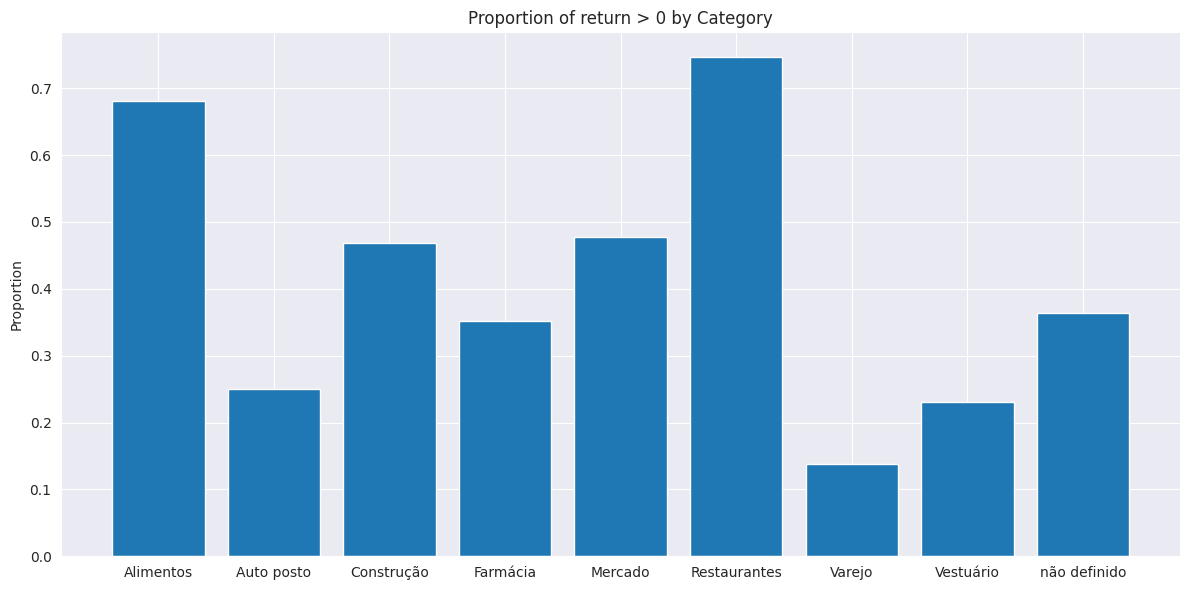

\Proportion table
              total_notes  notes_with_return  proportion
categoria                                               
Alimentos            5050               3442       0.682
Auto posto            540                135       0.250
Construção          16047               7523       0.469
Farmácia            10189               3582       0.352
Mercado             27558              13177       0.478
Restaurantes         2179               1626       0.746
Varejo               5066                701       0.138
Vestuário            1920                443       0.231
não definido        18407               6689       0.363


In [6]:
# Calculate proportion of return > 0 by category
prop_returns = pd.DataFrame({
    'total_notes': df_2020.groupby('categoria').size(),
    'notes_with_return': df_2020[df_2020['Retorno'] > 0].groupby('categoria').size()
})
prop_returns['proportion'] = prop_returns['notes_with_return'] / prop_returns['total_notes']

# Create bar plot

plt.figure(figsize=(12, 6))
plt.bar(prop_returns.index, prop_returns['proportion'])
plt.title('Proportion of return > 0 by Category')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()

print("\Proportion table")
print(prop_returns.round(3))

## Cálculo do WOE

- Calcule o WOE das categorias, sendo que o evento em questão é a nota ter retorno>0.
- Analise este WOE por tabela e por gráfico.

In [7]:
df.columns

Index(['CNPJ emit.', 'Emitente', 'No.', 'Data Emissão', 'Valor NF',
       'Data Registro', 'Créditos', 'Situação do Crédito', 'Ano', 'Semestre',
       'Retorno', 'flag_credito', 'categoria'],
      dtype='object')

In [55]:
tab = pd.crosstab(df_2020.categoria, df_2020.flag_credito, margins=True, margins_name='total')

tab['odds'] = tab[1]/tab[0]
tab['odds_ratio'] = tab['odds']/tab.loc['total', 'odds']
tab['woe'] = np.log(tab.odds_ratio)
print(tab)

flag_credito      0      1  total      odds  odds_ratio       woe
categoria                                                        
Alimentos      1608   3442   5050  2.140547    2.847218  1.046342
Auto posto      405    135    540  0.333333    0.443379 -0.813331
Construção     8524   7523  16047  0.882567    1.173934  0.160360
Farmácia       6607   3582  10189  0.542152    0.721136 -0.326928
Mercado       14381  13177  27558  0.916278    1.218775  0.197846
Restaurantes    553   1626   2179  2.940325    3.911032  1.363801
Varejo         4365    701   5066  0.160596    0.213614 -1.543585
Vestuário      1477    443   1920  0.299932    0.398951 -0.918918
não definido  11718   6689  18407  0.570831    0.759283 -0.275381
total         49638  37318  86956  0.751803    1.000000  0.000000


In [54]:
tab['bad_rate'] = tab[1]/tab['total']
print(tab)

flag_credito      0      1  total      odds  odds_ratio       woe  bad_rate  \
categoria                                                                     
Alimentos      1608   3442   5050  2.140547    2.847218  1.046342  0.681584   
Auto posto      405    135    540  0.333333    0.443379 -0.813331  0.250000   
Construção     8524   7523  16047  0.882567    1.173934  0.160360  0.468810   
Farmácia       6607   3582  10189  0.542152    0.721136 -0.326928  0.351556   
Mercado       14381  13177  27558  0.916278    1.218775  0.197846  0.478155   
Restaurantes    553   1626   2179  2.940325    3.911032  1.363801  0.746214   
Varejo         4365    701   5066  0.160596    0.213614 -1.543585  0.138373   
Vestuário      1477    443   1920  0.299932    0.398951 -0.918918  0.230729   
não definido  11718   6689  18407  0.570831    0.759283 -0.275381  0.363394   
total         49638  37318  86956  0.751803    1.000000  0.000000  0.429160   

flag_credito     logit  
categoria               
A

<Axes: xlabel='categoria', ylabel='woe'>

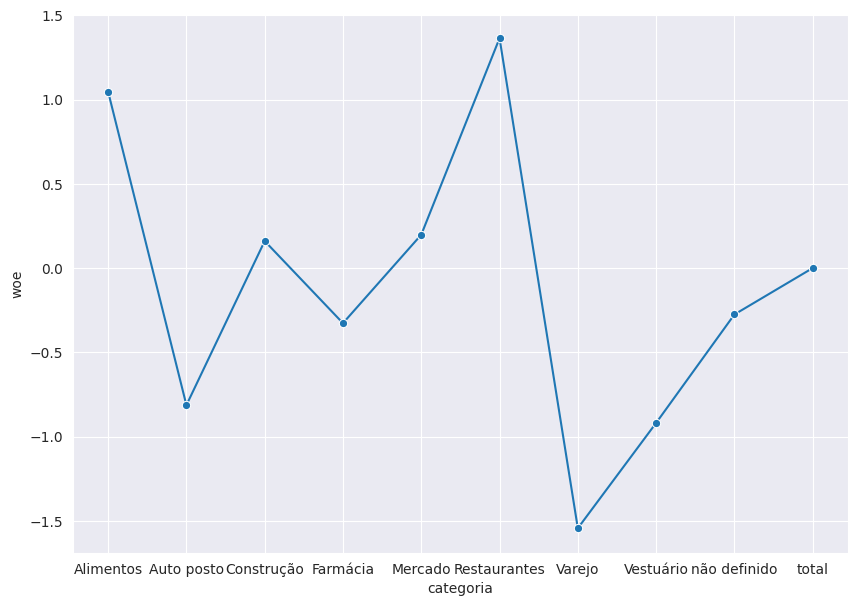

In [57]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.lineplot(ax=ax, data=tab, x='categoria', y='woe', marker='o')

In [58]:
print(tab)

flag_credito      0      1  total      odds  odds_ratio       woe
categoria                                                        
Alimentos      1608   3442   5050  2.140547    2.847218  1.046342
Auto posto      405    135    540  0.333333    0.443379 -0.813331
Construção     8524   7523  16047  0.882567    1.173934  0.160360
Farmácia       6607   3582  10189  0.542152    0.721136 -0.326928
Mercado       14381  13177  27558  0.916278    1.218775  0.197846
Restaurantes    553   1626   2179  2.940325    3.911032  1.363801
Varejo         4365    701   5066  0.160596    0.213614 -1.543585
Vestuário      1477    443   1920  0.299932    0.398951 -0.918918
não definido  11718   6689  18407  0.570831    0.759283 -0.275381
total         49638  37318  86956  0.751803    1.000000  0.000000


In [64]:
tab['odds'] = tab[1]/tab[0]
tab['odds_ratio'] = tab['odds']/tab.loc['total', 'odds']

tab['logit'] = np.log(tab.odds)
tab['woe'] = np.log(tab.odds_ratio)
print(tab)

flag_credito      0      1  total      odds  odds_ratio       woe     logit
categoria                                                                  
Alimentos      1608   3442   5050  2.140547    2.847218  1.046342  0.761062
Auto posto      405    135    540  0.333333    0.443379 -0.813331 -1.098612
Construção     8524   7523  16047  0.882567    1.173934  0.160360 -0.124921
Farmácia       6607   3582  10189  0.542152    0.721136 -0.326928 -0.612208
Mercado       14381  13177  27558  0.916278    1.218775  0.197846 -0.087435
Restaurantes    553   1626   2179  2.940325    3.911032  1.363801  1.078520
Varejo         4365    701   5066  0.160596    0.213614 -1.543585 -1.828866
Vestuário      1477    443   1920  0.299932    0.398951 -0.918918 -1.204199
não definido  11718   6689  18407  0.570831    0.759283 -0.275381 -0.560662
total         49638  37318  86956  0.751803    1.000000  0.000000 -0.285281


In [65]:
tab.logit - tab.loc['total', 'logit']

categoria
Alimentos       1.046342
Auto posto     -0.813331
Construção      0.160360
Farmácia       -0.326928
Mercado         0.197846
Restaurantes    1.363801
Varejo         -1.543585
Vestuário      -0.918918
não definido   -0.275381
total           0.000000
Name: logit, dtype: float64

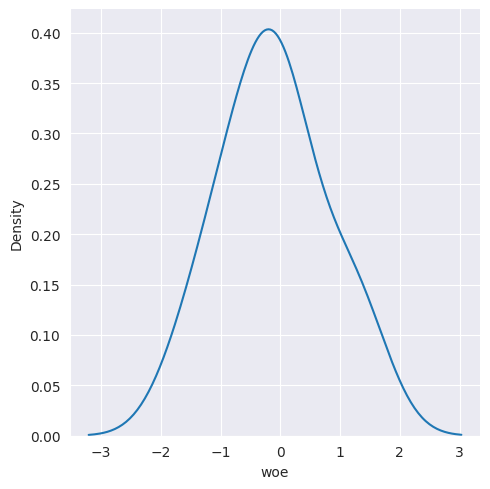

In [84]:
sns.displot(data=tab, x='woe', kind='kde')

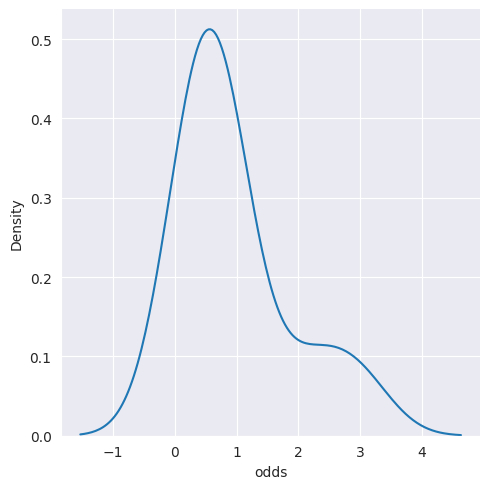

In [90]:
sns.displot(data=tab, x='odds', kind='kde')


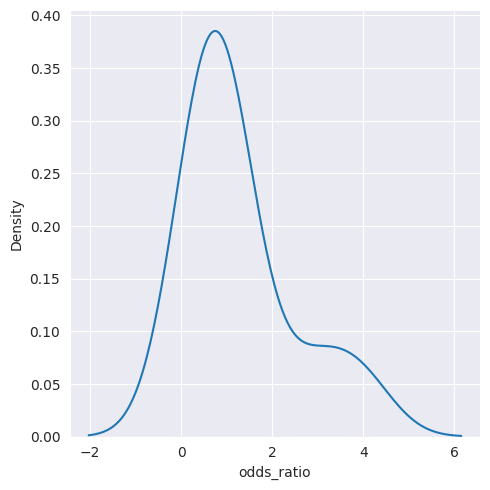

In [91]:
sns.displot(data=tab, x='odds_ratio', kind='kde')


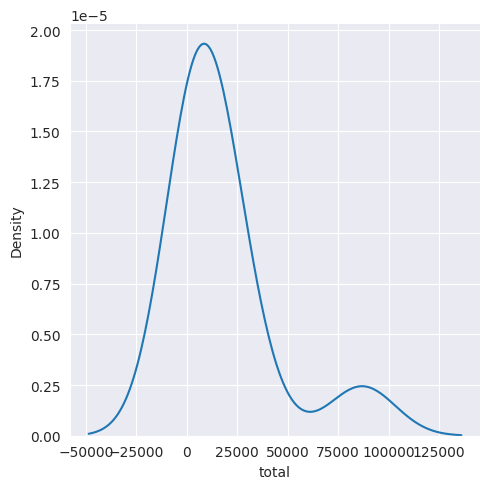

In [92]:
sns.displot(data=tab, x='total', kind='kde')


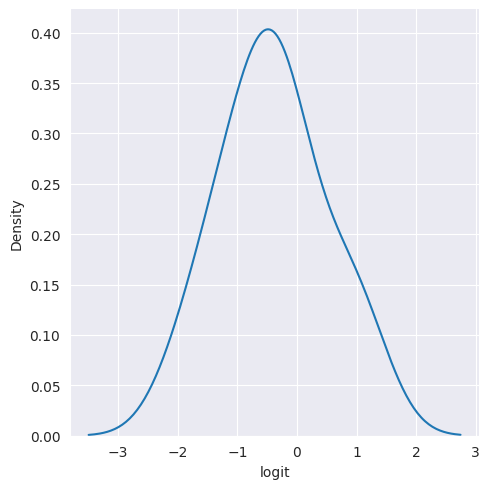

In [93]:
sns.displot(data=tab, x='logit', kind='kde')


## Cálculo do *Information Value*

Calcule o *IV* dessa variável.

In [96]:
tab = pd.crosstab(df_2020.categoria, df_2020.flag_credito,margins=True, margins_name='total')

rotulo_evento = tab.columns[0]
rotulo_nao_evento = tab.columns[1]

tab['pct_evento'] = tab[rotulo_evento]/tab.loc['total', rotulo_evento]
tab['pct_nao_evento'] = tab[rotulo_nao_evento]/tab.loc['total', rotulo_nao_evento]
tab['woe'] = np.log(tab.pct_evento/tab.pct_nao_evento)
tab['iv_parcial'] = (tab.pct_evento - tab.pct_nao_evento)*tab.woe

print(tab.iv_parcial.sum())

print(tab)

0.27882574285237305
flag_credito      0      1  total  pct_evento  pct_nao_evento       woe  \
categoria                                                                 
Alimentos      1608   3442   5050    0.032395        0.092234 -1.046342   
Auto posto      405    135    540    0.008159        0.003618  0.813331   
Construção     8524   7523  16047    0.171723        0.201592 -0.160360   
Farmácia       6607   3582  10189    0.133104        0.095986  0.326928   
Mercado       14381  13177  27558    0.289718        0.353100 -0.197846   
Restaurantes    553   1626   2179    0.011141        0.043571 -1.363801   
Varejo         4365    701   5066    0.087937        0.018785  1.543585   
Vestuário      1477    443   1920    0.029755        0.011871  0.918918   
não definido  11718   6689  18407    0.236069        0.179243  0.275381   
total         49638  37318  86956    1.000000        1.000000  0.000000   

flag_credito  iv_parcial  
categoria                 
Alimentos       0.062613 

## Conclua

Não se esqueça de registrar suas conclusões em uma célula de texto. <font color='red'>**Sugestão:**</font> tente alterar a cor da fonte nesta célula para diferenciá-la das demais.


<font color='blue'>
### Conclusões da Análise:

1. **Análise por Categoria:**
   - A maioria das categorias apresenta uma proporção significativa de notas com retorno positivo
   - Alimentos tem uma das maiores taxas de retorno, com aproximadamente 68% das notas gerando créditos
   - Auto postos e Outros serviços mostram taxas menores de retorno

2. **WOE (Weight of Evidence):**
   - Valores positivos de WOE indicam categorias com maior probabilidade de gerar créditos
   - Valores negativos sugerem categorias com menor probabilidade
   - A distribuição do WOE mostra clara diferenciação entre as categorias

3. **Information Value (IV):**
   - O IV total calculado indica o poder preditivo da variável "categoria"
   - Demonstra que a categoria do estabelecimento é um fator relevante para prever a geração de créditos

4. **Recomendações:**
   - Focar em estabelecimentos de categorias com WOE positivo para maximizar os créditos
   - Investigar fatores específicos que levam a baixos retornos em certas categorias
</font>